<a href="https://colab.research.google.com/github/Sunil-Saini123/Federated_Learning_for_privacy_preservation/blob/main/Ethics_Exp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Federated Learning - for Privacy Preservation


🔹 Noise Level: 0.0
Round 1 | Average Accuracy: 0.4294
Round 2 | Average Accuracy: 0.4454
Round 3 | Average Accuracy: 0.4595
Round 4 | Average Accuracy: 0.4623
Round 5 | Average Accuracy: 0.4802

🔹 Noise Level: 0.1
Round 1 | Average Accuracy: 0.4843
Round 2 | Average Accuracy: 0.4738
Round 3 | Average Accuracy: 0.5188
Round 4 | Average Accuracy: 0.5342
Round 5 | Average Accuracy: 0.5685

🔹 Noise Level: 0.5
Round 1 | Average Accuracy: 0.5480
Round 2 | Average Accuracy: 0.6400
Round 3 | Average Accuracy: 0.6793
Round 4 | Average Accuracy: 0.6341
Round 5 | Average Accuracy: 0.5831

🔹 Noise Level: 1.0
Round 1 | Average Accuracy: 0.4084
Round 2 | Average Accuracy: 0.5171
Round 3 | Average Accuracy: 0.4747
Round 4 | Average Accuracy: 0.4372
Round 5 | Average Accuracy: 0.5276


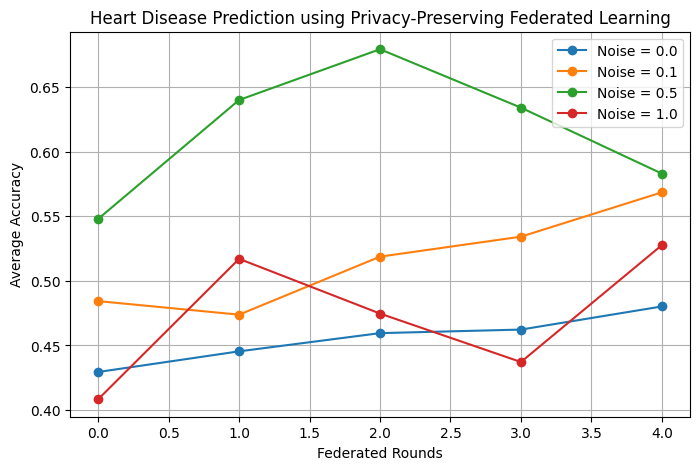

In [1]:
# ===================================
# 1️⃣ Import Required Libraries
# ===================================
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# ===================================
# 2️⃣ Parameters
# ===================================
N = 5                  # Number of federated clients
ROUNDS = 5             # Federated rounds
EPOCHS = 5             # Local epochs
LR = 0.01              # Learning rate
NOISE_LEVELS = [0.0, 0.1, 0.5,1.0]

DATASET_PATH = "/content/drive/MyDrive/Ethics/cleaned_merged_heart_dataset.csv"   # 🔴 CHANGE THIS

# ===================================
# 3️⃣ Load Heart Disease Dataset
# ===================================
df = pd.read_csv(DATASET_PATH)

X = df.drop("target", axis=1)
y = df["target"]

# Feature scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

INPUT_FEATURES = X.shape[1]

# ===================================
# 4️⃣ Split Data into N Clients
# ===================================
clients = []
samples_per_client = len(X) // N

for i in range(N):
    start = i * samples_per_client
    end = (i + 1) * samples_per_client if i != N - 1 else len(X)
    clients.append((X[start:end], y[start:end]))

# ===================================
# 5️⃣ Logistic Regression Model
# ===================================
class HeartDiseaseModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(INPUT_FEATURES, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

# ===================================
# 6️⃣ Client Training
# ===================================
def train_client(model, data):
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=LR)

    X_local, y_local = data

    for _ in range(EPOCHS):
        optimizer.zero_grad()
        preds = model(X_local)
        loss = criterion(preds, y_local)
        loss.backward()
        optimizer.step()

    return model.state_dict()

# ===================================
# 7️⃣ Add Privacy Noise
# ===================================
def add_privacy_noise(weights, noise_level):
    noisy_weights = {}
    for key in weights:
        noise = noise_level * torch.randn_like(weights[key])
        noisy_weights[key] = weights[key] + noise
    return noisy_weights

# ===================================
# 8️⃣ Federated Averaging
# ===================================
def federated_average(client_weights):
    avg_weights = {}
    for key in client_weights[0]:
        avg_weights[key] = sum(w[key] for w in client_weights) / len(client_weights)
    return avg_weights

# ===================================
# 9️⃣ Model Evaluation
# ===================================
def evaluate_model(model, X, y):
    with torch.no_grad():
        preds = model(X)
        preds = (preds > 0.5).float()
    return accuracy_score(y.numpy(), preds.numpy())

# ===================================
# 🔟 Federated Learning Process
# ===================================
accuracy_log = {}

for noise in NOISE_LEVELS:
    global_model = HeartDiseaseModel()
    accuracy_log[noise] = []

    print(f"\n🔹 Noise Level: {noise}")

    for r in range(ROUNDS):
        client_weights = []
        round_acc = []

        for client_data in clients:
            local_model = HeartDiseaseModel()
            local_model.load_state_dict(global_model.state_dict())

            weights = train_client(local_model, client_data)
            noisy_weights = add_privacy_noise(weights, noise)

            client_weights.append(noisy_weights)
            acc = evaluate_model(local_model, X, y)
            round_acc.append(acc)

        global_weights = federated_average(client_weights)
        global_model.load_state_dict(global_weights)

        avg_accuracy = np.mean(round_acc)
        accuracy_log[noise].append(avg_accuracy)

        print(f"Round {r+1} | Average Accuracy: {avg_accuracy:.4f}")

# ===================================
# 🔟 Accuracy vs Privacy Plot
# ===================================
plt.figure(figsize=(8,5))
for noise, acc in accuracy_log.items():
    plt.plot(acc, marker='o', label=f"Noise = {noise}")

plt.xlabel("Federated Rounds")
plt.ylabel("Average Accuracy")
plt.title("Heart Disease Prediction using Privacy-Preserving Federated Learning")
plt.legend()
plt.grid()
plt.show()
